# クレジットカード審査項目別延滞率

## 仮想データ作成（5000件）

In [ ]:
import numpy as np
import pandas as pd

n = 5000
np.random.seed(42)


# 年齢（ランダム、20～60歳）
age = np.random.randint(20,60,n)

# 年収（年齢から、200～1000万円）
annual_income = age*10 + np.random.normal(0,80,n)
annual_income = np.clip(annual_income,200,1000)

# 勤続年数（年齢から、0～30年）
employment_years = age-22 + np.random.normal(0,3,n)
employment_years = np.clip(employment_years,0,30)


# 延滞リスク（年齢、年収、勤続年数から）

risk_factor = (
    0.6*(age < 30)
    + 0.4*(annual_income < 250)
    + 0.3*(employment_years < 1)
)


# 他社延滞回数（0～6回）

other_default_count = np.random.poisson(0.3 + risk_factor, n)
other_default_count = np.clip(other_default_count,0,6)


# 他社延滞金額(0～200万円)

other_default_amount = other_default_count*np.random.randint(5,30,n)
other_default_amount = np.clip(other_default_amount,0,200)

# 他社借入金額（年収・延滞回数から、0～500万円）

other_loan_amount = (
    + 40*other_default_count
    + np.random.normal(0,40,n)
)
other_loan_amount = np.clip(other_loan_amount,0,500)


# 自社延滞回数(0～6回)

self_default_count = np.random.poisson(0.2 + risk_factor*0.8, n)
self_default_count = np.clip(self_default_count,0,6)

# 自社延滞金額（0～50万円）

self_default_amount = self_default_count * np.random.randint(5,30,n)
self_default_amount = np.clip(self_default_amount,0,50)

# 自社借入金額（年収・延滞回数から、0～100万円）

self_loan_amount = (
    + 30*self_default_count
    + np.random.normal(0,20,n)
)

self_loan_amount = np.clip(self_loan_amount,0,100)


# 延滞確率
prob_default = (
    0.02
    + 0.03*self_default_count
    + 0.02*other_default_count
    + 0.004*self_default_amount
    + 0.003*other_default_amount
    + 0.004*self_loan_amount
    + 0.003*other_loan_amount
    + 0.04*(age < 25)
    - 0.00002*annual_income
    - 0.002*employment_years
)

prob_default = np.clip(prob_default,0.01,0.40)


# 延滞フラグ

default_flag = np.random.binomial(1,prob_default,n)


# DataFrame

df_all_approved = pd.DataFrame({
    "age":age,
    "annual_income":annual_income,
    "employment_years":employment_years,
    "other_loan_amount":other_loan_amount,
    "self_loan_amount":self_loan_amount,
    "other_default_count":other_default_count,
    "self_default_count":self_default_count,
    "other_default_amount":other_default_amount,
    "self_default_amount":self_default_amount,
    "default_flag":default_flag
})

## 項目別延滞率との相関

### SQLで項目別延滞率

In [ ]:

import sqlite3
conn = sqlite3.connect("my_data.db")
df_all_approved.to_sql("loan_applications", conn, if_exists="replace", index=False)



# 年齢別

query1 = """

SELECT
  CASE WHEN age < 30 THEN '10-20s'
       WHEN age < 40 THEN '30s'
       WHEN age < 50 THEN '40s'
       ELSE '50s+'
    END AS age_group,
    COUNT(*) AS Number,
    AVG(default_flag) AS default_rate
FROM loan_applications
GROUP BY age_group

"""
df_age = pd.read_sql_query(query1, conn)


# 年収別

query2 = """
SELECT
  CASE WHEN annual_income < 300 THEN '200〜299万'
       WHEN annual_income < 400 THEN '300〜399万'
       WHEN annual_income < 500 THEN '400〜499万'
       ELSE '600〜1000万'
    END AS income_group,
    COUNT(*) AS Number,
    AVG(default_flag) AS default_rate
FROM loan_applications
GROUP BY income_group


"""
df_income = pd.read_sql_query(query2, conn)


# 勤続年数別

query3 = """

SELECT
  CASE WHEN employment_years <= 10 THEN '0~10年'
       WHEN employment_years <= 20 THEN '11~20年'
       WHEN employment_years <= 25 THEN '21~25年'
       ELSE '26~30年'
    END AS emp_group,
    COUNT(*) AS Number,
    AVG(default_flag) AS default_rate
FROM loan_applications
GROUP BY emp_group

"""
df_emp = pd.read_sql_query(query3, conn)


# 他社延滞件数別

query4 = """

SELECT
CASE WHEN other_default_count = 0 THEN '0件'
     WHEN other_default_count <= 2 THEN '1~2件'
     ELSE '3~6件'
  END AS other_default_count_group,
  COUNT(*) AS Number,
  AVG(default_flag) AS default_rate
FROM loan_applications
GROUP BY other_default_count_group

"""
df_other_default_count = pd.read_sql_query(query4, conn)

# 他社延滞金額別

query5 = """

SELECT
CASE WHEN other_default_amount <= 25 THEN '0~25万'
     WHEN other_default_amount <= 50 THEN '26~50万'
     ELSE '51-200万'
  END AS other_default_amount_group,
  COUNT(*) AS Number,
  AVG(default_flag) AS default_rate
FROM loan_applications
GROUP BY other_default_amount_group

"""

df_other_default_amount= pd.read_sql_query(query5, conn)


# 他社借入金額別

query6 = """

SELECT
CASE WHEN other_loan_amount <= 25 THEN '0~25万'
     WHEN other_loan_amount <= 50 THEN '26~50万'
     WHEN other_loan_amount <= 200 THEN '51~200万'
     ELSE '201-500万'
  END AS other_loan_amount_group,
  COUNT(*) AS Number,
  AVG(default_flag) AS default_rate
FROM loan_applications
GROUP BY other_loan_amount_group
ORDER BY
CASE other_loan_amount_group
     WHEN '0~25万' THEN 1
     WHEN '26~50万' THEN 2
     WHEN '51~200万' THEN 3
     WHEN '201-500万' THEN 4
END

"""

df_other_loan_amount= pd.read_sql_query(query6, conn)


# 自社延滞件数別

query7 = """

SELECT
CASE WHEN self_default_count = 0 THEN '0件'
     WHEN self_default_count <= 2 THEN '1~2件'
     ELSE '3~6件'
  END AS self_default_count_group,
  COUNT(*) AS Number,
  AVG(default_flag) AS default_rate
FROM loan_applications
GROUP BY self_default_count_group

"""
df_self_default_count = pd.read_sql_query(query7, conn)

# 自社延滞金額別

query8 = """

SELECT
CASE WHEN self_default_amount <= 10 THEN '0~10万'
     WHEN self_default_amount <= 30 THEN '11~30万'
     ELSE '31~50万'
  END AS self_default_amount_group,
  COUNT(*) AS Number,
  AVG(default_flag) AS default_rate
FROM loan_applications
GROUP BY self_default_amount_group

"""

df_self_default_amount= pd.read_sql_query(query8, conn)


# 自社借入金額別

query9 = """

SELECT
CASE WHEN self_loan_amount <= 20 THEN '0~20万'
     WHEN self_loan_amount <= 40 THEN '21~40万'
     WHEN self_loan_amount <= 60 THEN '41~60万'
     ELSE '61-100万'
  END AS self_loan_amount_group,
  COUNT(*) AS Number,
  AVG(default_flag) AS default_rate
FROM loan_applications
GROUP BY self_loan_amount_group

"""

df_self_loan_amount= pd.read_sql_query(query9, conn)

#平均延滞率

query10 = """
SELECT AVG(default_flag) FROM loan_applications
"""
df_default_flag= pd.read_sql_query(query10, conn)

conn.close()

print(df_default_flag)
print(df_age)
print(df_income)
print(df_emp)
print(df_other_default_count)
print(df_other_default_amount)
print(df_other_loan_amount)
print(df_self_default_count)
print(df_self_default_amount)
print(df_self_loan_amount)

   AVG(default_flag)
0             0.1798
  age_group  Number  default_rate
0    10-20s    1202      0.335275
1       30s    1239      0.154157
2       40s    1300      0.124615
3      50s+    1259      0.113582
  income_group  Number  default_rate
0     200〜299万    1357      0.273397
1     300〜399万    1195      0.181590
2     400〜499万    1194      0.135678
3    600〜1000万    1254      0.118820
  emp_group  Number  default_rate
0     0~10年    1527      0.300589
1    11~20年    1256      0.141720
2    21~25年     660      0.148485
3    26~30年    1557      0.105331
  other_default_count_group  Number  default_rate
0                        0件    3087      0.108844
1                      1~2件    1691      0.280899
2                      3~6件     222      0.396396
  other_default_amount_group  Number  default_rate
0                      0~25万    4302      0.149465
1                     26~50万     514      0.356031
2                    51-200万     184      0.396739
  other_loan_amount_group  Nu

### 項目別延滞率グラフ化

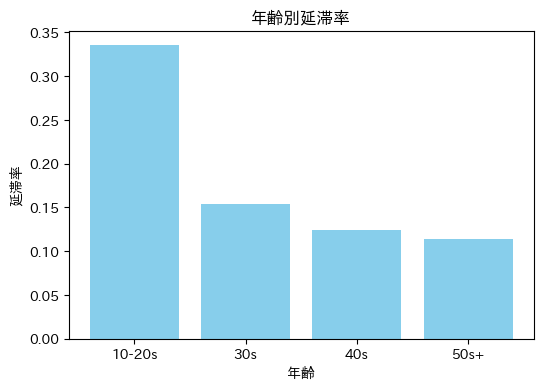

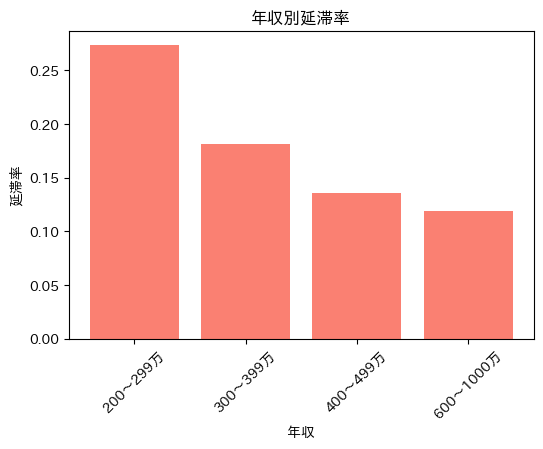

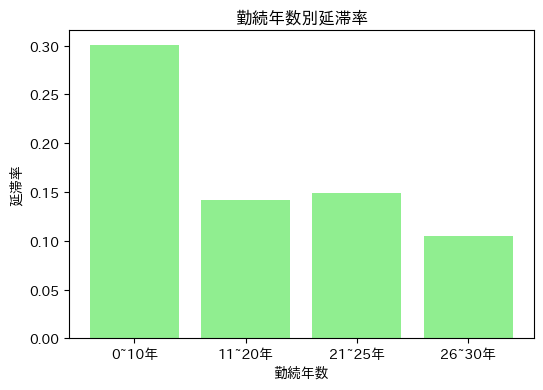

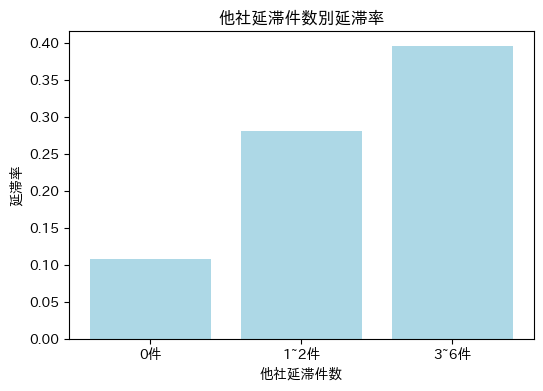

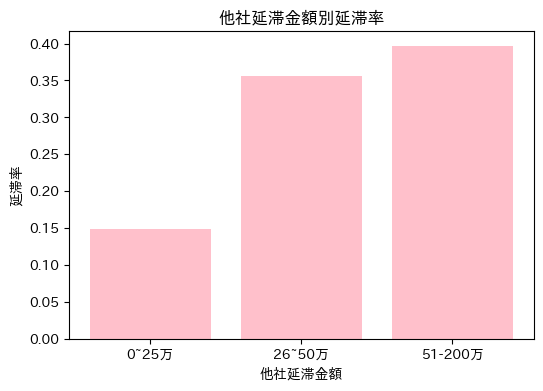

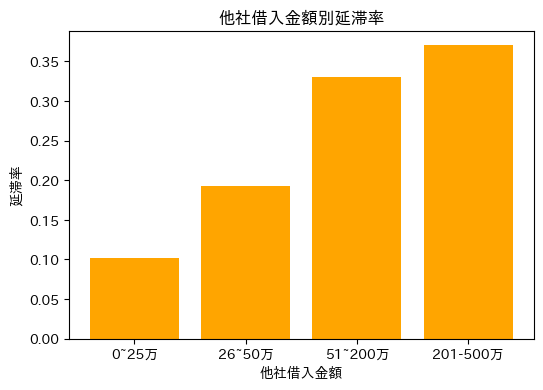

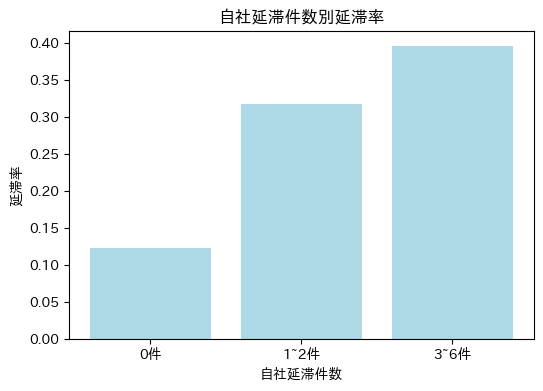

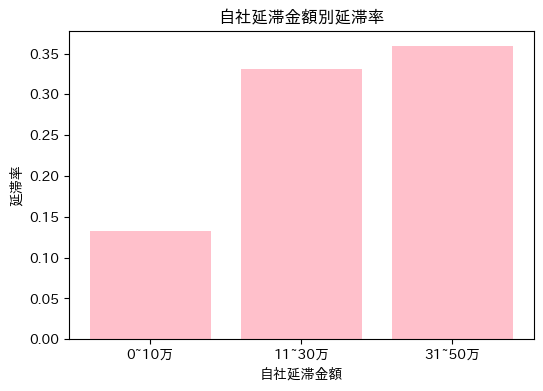

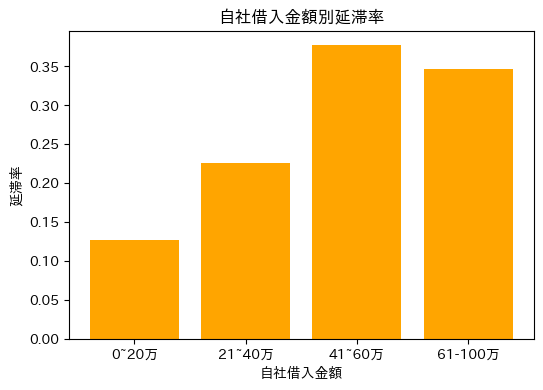

In [ ]:

!pip install japanize-matplotlib

import matplotlib.pyplot as plt
import japanize_matplotlib

# 年齢別
plt.figure(figsize=(6,4))
plt.bar(df_age['age_group'], df_age['default_rate'], color='skyblue')
plt.xlabel("年齢")
plt.ylabel("延滞率")
plt.title("年齢別延滞率")
plt.show()

# 年収別
plt.figure(figsize=(6,4))
plt.bar(df_income['income_group'], df_income['default_rate'], color='salmon')
plt.xlabel("年収")
plt.ylabel("延滞率")
plt.title("年収別延滞率")
plt.xticks(rotation=45)
plt.show()

# 勤続年数別
plt.figure(figsize=(6,4))
plt.bar(df_emp['emp_group'], df_emp['default_rate'], color='lightgreen')
plt.xlabel("勤続年数")
plt.ylabel("延滞率")
plt.title("勤続年数別延滞率")
plt.show()

# 他社延滞件数別
plt.figure(figsize=(6,4))
plt.bar(df_other_default_count['other_default_count_group'], df_other_default_count['default_rate'], color='lightblue')
plt.xlabel("他社延滞件数")
plt.ylabel("延滞率")
plt.title("他社延滞件数別延滞率")
plt.show()

# 他社延滞金額別
plt.figure(figsize=(6,4))
plt.bar(df_other_default_amount['other_default_amount_group'], df_other_default_amount['default_rate'], color='pink')
plt.xlabel("他社延滞金額")
plt.ylabel("延滞率")
plt.title("他社延滞金額別延滞率")
plt.show()

# 他社借入金額別
plt.figure(figsize=(6,4))
plt.bar(df_other_loan_amount['other_loan_amount_group'], df_other_loan_amount['default_rate'], color='orange')
plt.xlabel("他社借入金額")
plt.ylabel("延滞率")
plt.title("他社借入金額別延滞率")
plt.show()

# 自社延滞件数別
plt.figure(figsize=(6,4))
plt.bar(df_self_default_count['self_default_count_group'], df_self_default_count['default_rate'], color='lightblue')
plt.xlabel("自社延滞件数")
plt.ylabel("延滞率")
plt.title("自社延滞件数別延滞率")
plt.show()

# 自社延滞金額別
plt.figure(figsize=(6,4))
plt.bar(df_self_default_amount['self_default_amount_group'], df_self_default_amount['default_rate'], color='pink')
plt.xlabel("自社延滞金額")
plt.ylabel("延滞率")
plt.title("自社延滞金額別延滞率")
plt.show()

# 自社借入金額別
plt.figure(figsize=(6,4))
plt.bar(df_self_loan_amount['self_loan_amount_group'], df_self_loan_amount['default_rate'], color='orange')
plt.xlabel("自社借入金額")
plt.ylabel("延滞率")
plt.title("自社借入金額別延滞率")
plt.show()



### ロジスティック回帰で延滞率モデル作成

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


再現率:0.71
[[563 248]
 [ 54 135]]
AUC:0.78


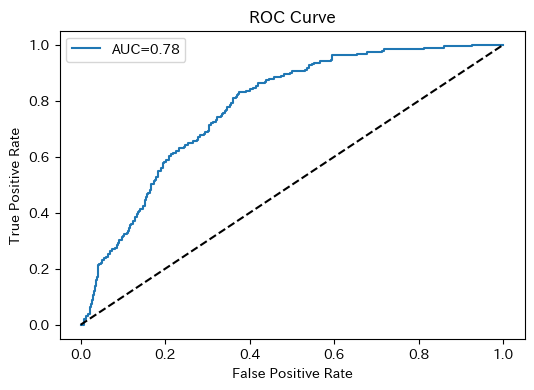

In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix,precision_score,recall_score,f1_score,roc_curve,roc_auc_score


# 説明変数
x = df_all_approved[['age', 'annual_income', 'employment_years',
                     'other_default_count','other_default_amount','other_loan_amount',
                     'self_default_count','self_default_amount','self_loan_amount']]

# 目的変数
y=df_all_approved['default_flag']

# 学習とテストに分ける
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

# モデル生成　(不均等データのため重さ調整)
model=LogisticRegression(class_weight='balanced')

# 学習
model.fit(x_train,y_train)

# 延滞確率
y_prob = model.predict_proba(x_test)[:,1]

# 閾値 (再現率高めになるよう設定)
threshold = 0.47

# 予測
y_pred = (y_prob > threshold).astype(int)


#-----------------------------
# 評価
#-----------------------------

# 再現率
recall=recall_score(y_test,y_pred)
print(f'再現率:{recall:.2f}')

# 混同行列
matrix=confusion_matrix(y_test,y_pred)
print(matrix)

# ROC-AUC
auc=roc_auc_score(y_test,y_prob)
print(f'AUC:{auc:.2f}')

fpr,tpr,thresholds=roc_curve(y_test,y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr,tpr,label=f'AUC={auc:.2f}')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

### 項目別影響度



       項目        係数       影響度
3  他社延滞回数 -0.159294  0.159294
6  自社延滞回数 -0.151429  0.151429
0      年齢 -0.031463  0.031463
7  自社延滞金額  0.021863  0.021863
8  自社借入金額  0.017637  0.017637
4  他社延滞金額  0.015840  0.015840
5  他社借入金額  0.013017  0.013017
2    勤続年数  0.006011  0.006011
1      年収  0.000498  0.000498


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

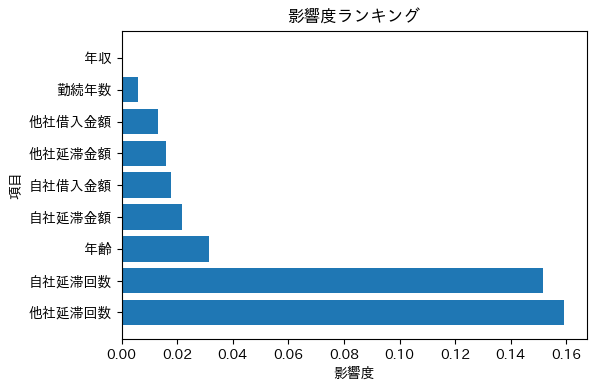

In [ ]:

coef = pd.DataFrame({
    "項目": x.columns,
    "係数": model.coef_[0]
})

name_dict={
      'age':'年齢',
      'annual_income':'年収',
      'employment_years':'勤続年数',
      'other_default_count':'他社延滞回数',
      'other_default_amount':'他社延滞金額',
      'other_loan_amount':'他社借入金額',
      'self_default_count':'自社延滞回数',
      'self_default_amount':'自社延滞金額',
      'self_loan_amount':'自社借入金額'
}
coef["項目"] = coef["項目"].map(name_dict)


# 影響度ランキング
coef["影響度"] = coef["係数"].abs()

coef = coef.sort_values("影響度", ascending=False)

print(coef)

# Excelダウンロード
coef.to_excel('影響度ランキング.xlsx',index=False)
from google.colab import files
files.download('影響度ランキング.xlsx')

# 影響度ランキンググラフ
plt.figure(figsize=(6,4))
plt.barh(coef["項目"], coef["影響度"])

plt.title("影響度ランキング")
plt.xlabel("影響度")
plt.ylabel("項目")

plt.show()